In [1]:
import sqlite3

# Connect to database (creates it if it doesn't exist)
conn = sqlite3.connect("sales_data.db")
cursor = conn.cursor()

# Create sales table
cursor.execute('''
    CREATE TABLE IF NOT EXISTS sales (
        id INTEGER PRIMARY KEY AUTOINCREMENT,
        product TEXT NOT NULL,
        quantity INTEGER NOT NULL,
        price REAL NOT NULL
    )
''')

# Insert sample data
sample_data = [
    ('Laptop', 2, 50000),
    ('Mouse', 10, 500),
    ('Keyboard', 5, 1500),
    ('Monitor', 3, 12000),
    ('Laptop', 1, 50000),
    ('Mouse', 4, 500)
]

cursor.executemany('INSERT INTO sales (product, quantity, price) VALUES (?, ?, ?)', sample_data)
conn.commit()
conn.close()


    product  total_quantity  total_revenue
0  Keyboard               5         7500.0
1    Laptop               3       150000.0
2   Monitor               3        36000.0
3     Mouse              14         7000.0


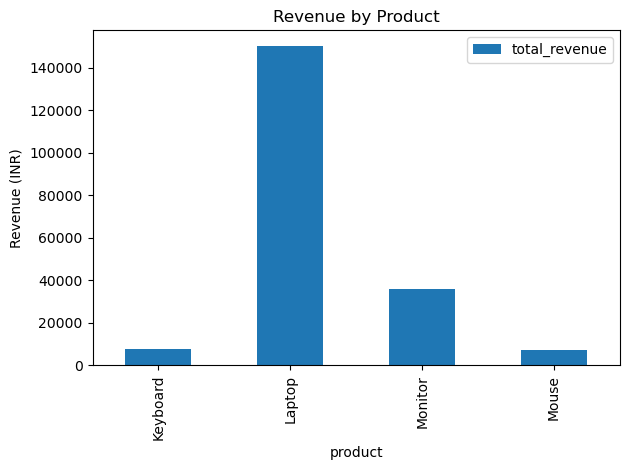

In [2]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

# Connect to the database
conn = sqlite3.connect("sales_data.db")

# Run SQL query
query = '''
SELECT product,
       SUM(quantity) AS total_quantity,
       SUM(quantity * price) AS total_revenue
FROM sales
GROUP BY product
'''
df = pd.read_sql_query(query, conn)
conn.close()

# Display results
print(df)

# Plot bar chart
df.plot(kind='bar', x='product', y='total_revenue', title='Revenue by Product')
plt.ylabel('Revenue (INR)')
plt.tight_layout()
plt.savefig("sales_chart.png")
plt.show()
